In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split , StratifiedKFold , cross_val_score , GridSearchCV 

from sklearn.impute import  KNNImputer

from sklearn.preprocessing import RobustScaler 

from sklearn.neighbors import KNeighborsClassifier 

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score , confusion_matrix , precision_score , recall_score , f1_score , classification_report

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
original_data = pd.read_csv('../Dataset/Message_Intelligence_Dataset.csv')

df = original_data.copy()

df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


## Basic Info.

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   object 
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   object 
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week             

,message_id,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5094.000000,5087.000000,5038.000000,5200.000000,5200.000000,5200.000000
mean,902600.500000,75.035962,11.457308,0.206538,1.681346,0.243654,0.246346,0.817692,54.836317,296.671909,8.301906,11.523462,3.038846,0.187115
std,1501.255031,12.455377,1.609056,0.404860,2.415846,0.545363,0.676798,0.556687,17.697943,191.748754,5.586503,6.861518,2.062504,0.390042
min,900001.000000,32.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,901300.750000,67.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.100000,148.000000,5.000000,6.000000,1.000000,0.000000
50%,902600.500000,74.000000,11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,54.800000,275.000000,7.000000,12.000000,3.000000,0.000000
75%,903900.250000,81.000000,13.000000,0.000000,4.000000,0.000000,0.000000,1.000000,66.600000,410.500000,10.000000,17.000000,5.000000,0.000000
max,905200.000000,122.000000,16.000000,1.000000,9.000000,2.000000,3.000000,2.000000,100.000000,1500.000000,38.000000,23.000000,6.000000,1.000000


In [4]:
df.shape

(5200, 16)

## Dropping Duplicates

In [5]:
df.duplicated().sum()

np.int64(0)

### Therefore, there are no duplicates in data.

## EDA ( Exploratory Data Analysis )

### Univariate Analysis 

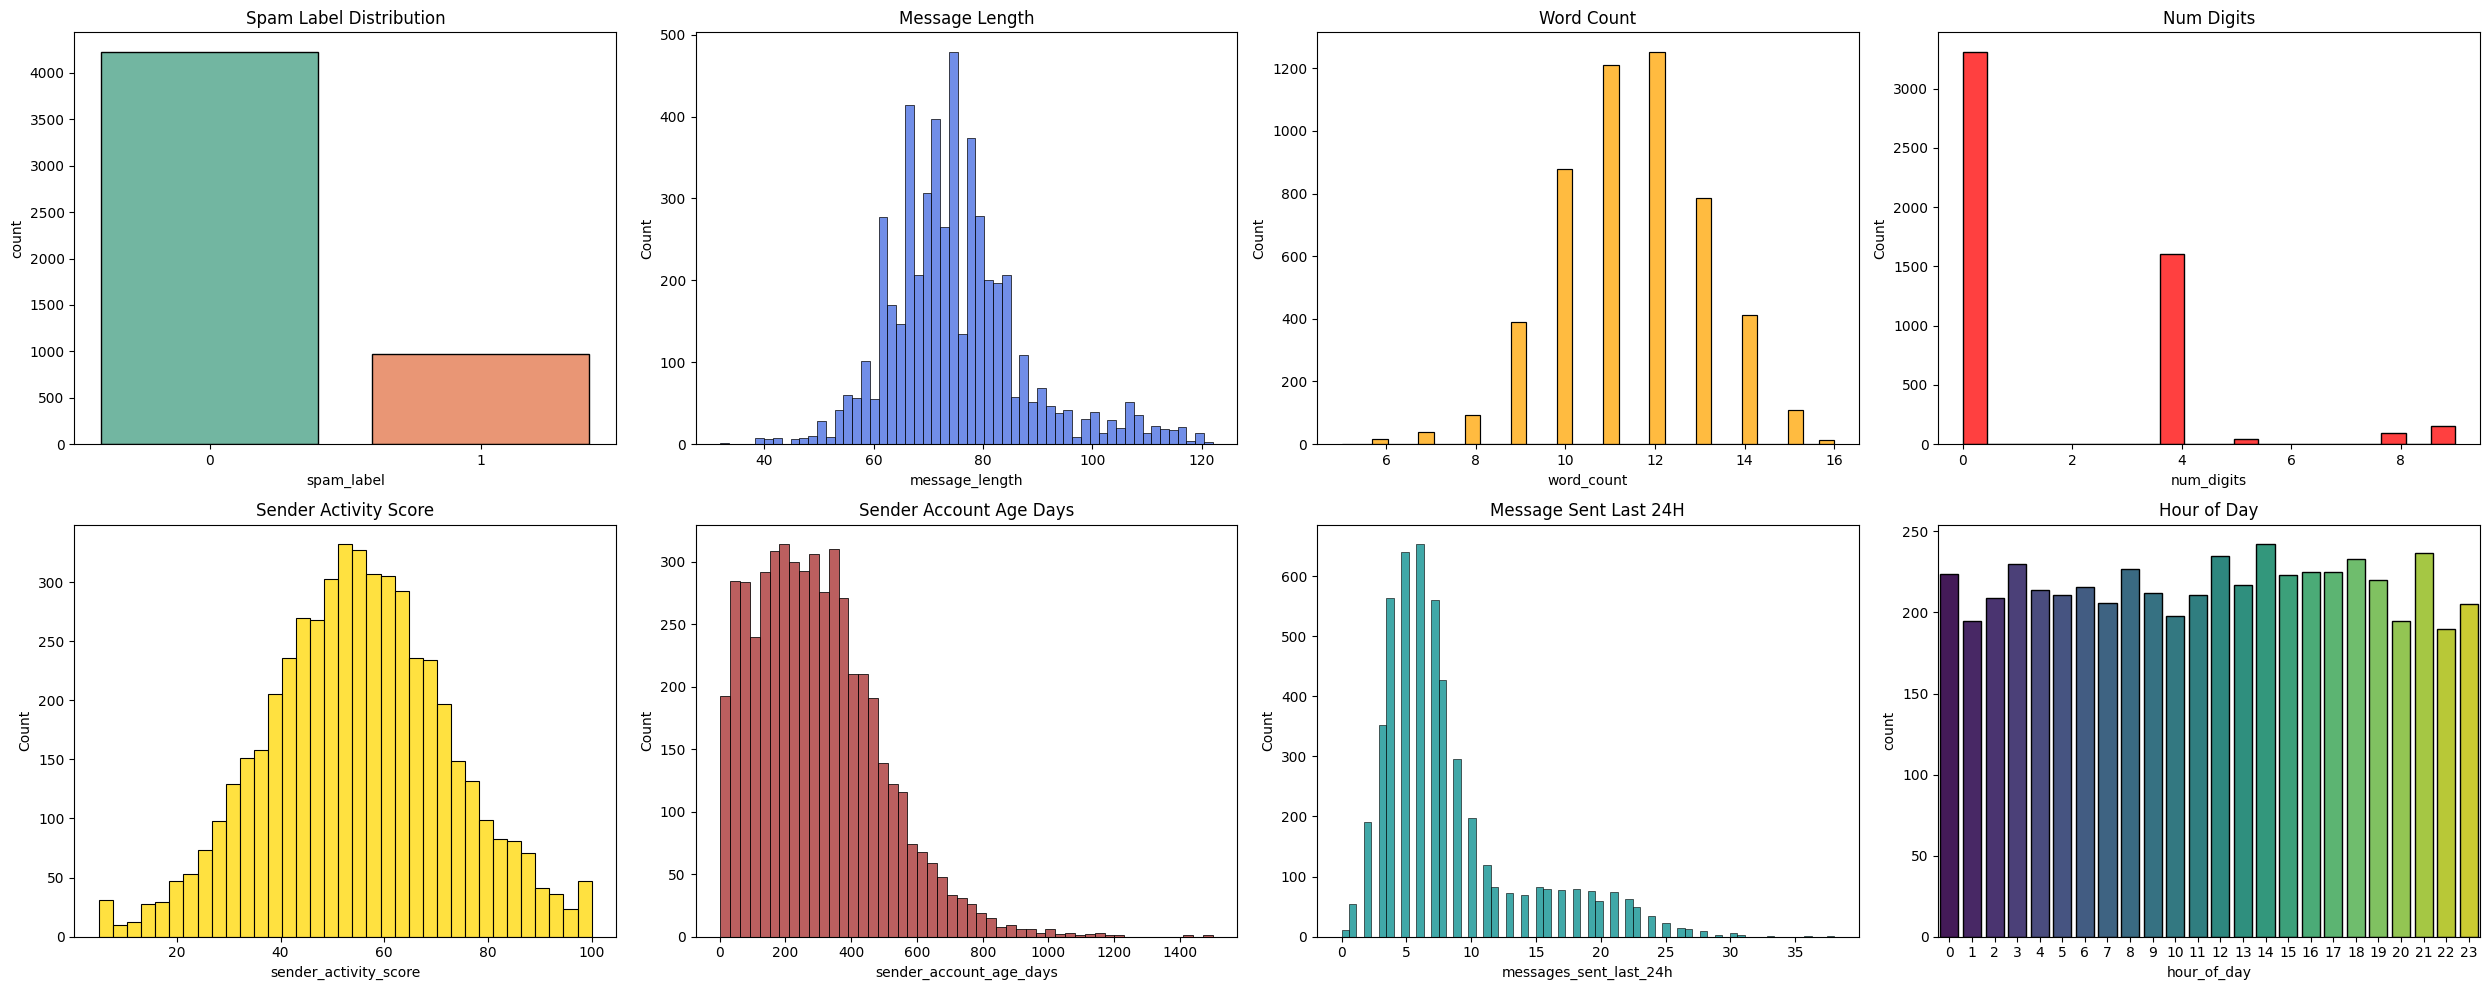

In [6]:
fig , axes = plt.subplots( 2 , 4 , figsize = (25 , 10))

sns.countplot(x = 'spam_label', data = df, palette = 'Set2', edgecolor = 'black' , ax = axes[0,0])
axes[0,0].set_title("Spam Label Distribution")

sns.histplot(df['message_length'], color='royalblue', edgecolor = 'black' , ax=axes[0,1])
axes[0,1].set_title("Message Length")

sns.histplot(df['word_count'], color='orange', edgecolor = 'black' , ax=axes[0,2])
axes[0,2].set_title("Word Count")

sns.histplot(df['num_digits'], color='red', edgecolor = 'black' , ax=axes[0,3])
axes[0,3].set_title("Num Digits")

sns.histplot(df['sender_activity_score'], color='gold', edgecolor = 'black' , ax=axes[1,0])
axes[1,0].set_title("Sender Activity Score")

sns.histplot(df['sender_account_age_days'], color='brown', edgecolor = 'black' , ax=axes[1,1])
axes[1,1].set_title("Sender Account Age Days")

sns.histplot(df['messages_sent_last_24h'], color='darkcyan', edgecolor = 'black' , ax=axes[1,2])
axes[1,2].set_title("Message Sent Last 24H")

sns.countplot(x = 'hour_of_day' , data = df , palette = 'viridis' , edgecolor = 'black' , ax=axes[1,3])
axes[1,3].set_title("Hour of Day")

plt.tight_layout()
plt.show()

### The Univariate Analysis indicates that, Spam Label (Target Class) has Moderate Imbalanced data. Other Numerical features like Sender Account Age days and Message Sent Last 24H has High Positive / Right Skewness.

### Bivariate Analysis 

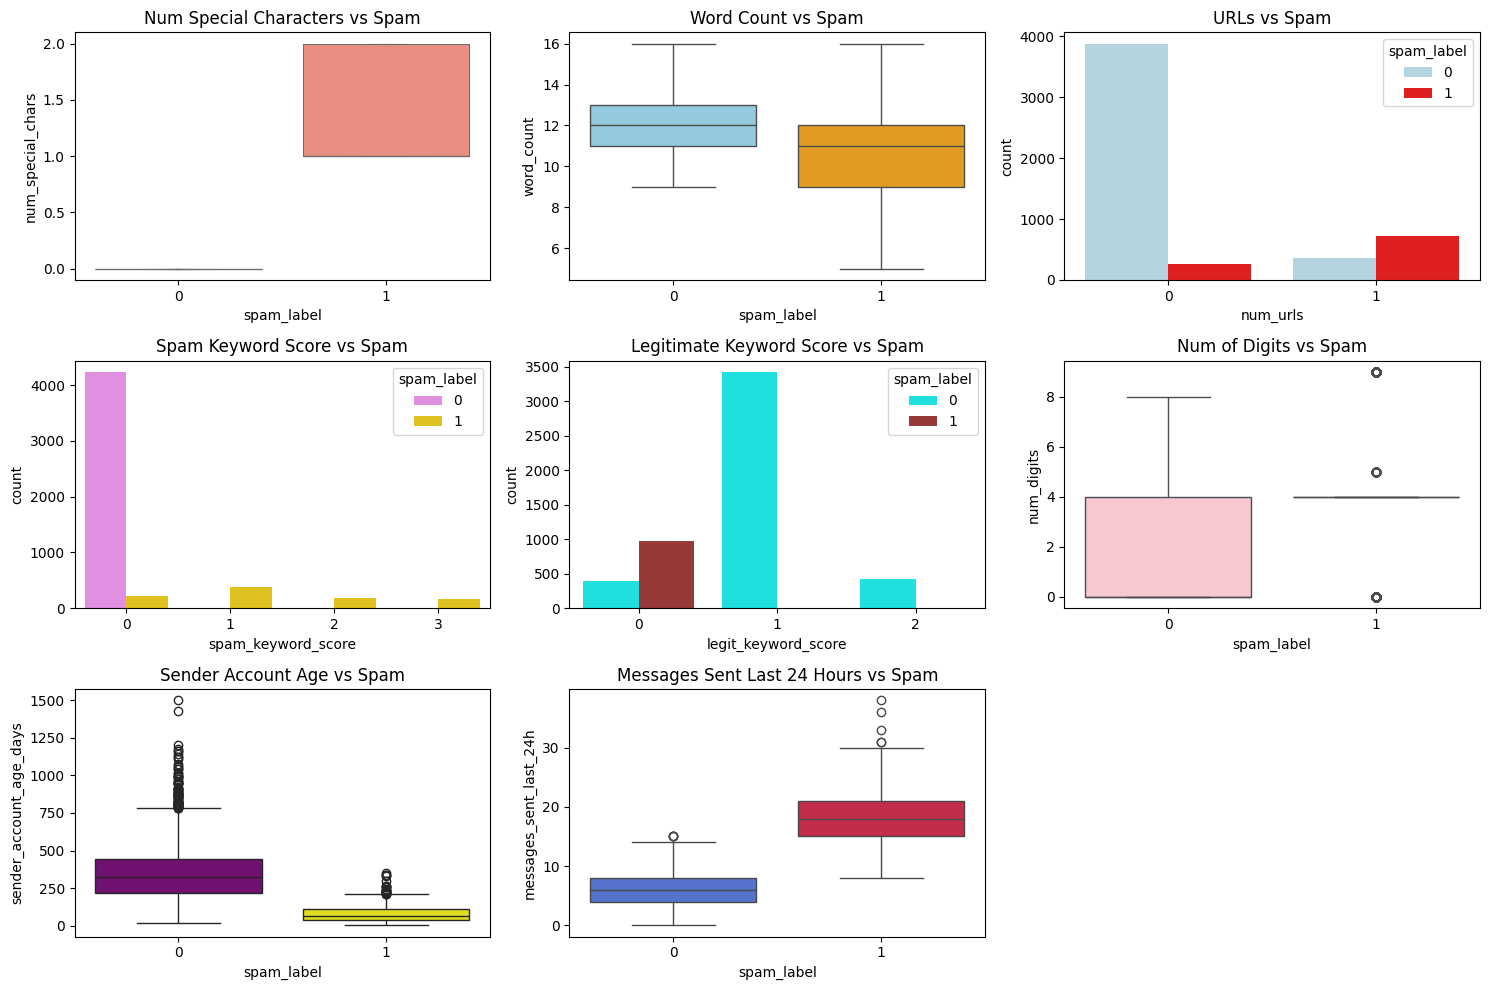

In [7]:
fig, ax = plt.subplots(3,3, figsize=(15,10))

sns.boxenplot( x = 'spam_label', y = 'num_special_chars' , data = df , palette = ['lightgreen','salmon'] , ax =  ax[0,0])
ax[0,0].set_title("Num Special Characters vs Spam")

sns.boxplot( x ='spam_label', y ='word_count', data = df , palette = ['skyblue','orange'] , ax = ax[0,1])
ax[0,1].set_title("Word Count vs Spam")

sns.countplot( x = 'num_urls' , hue = 'spam_label' , data = df , palette = ['lightblue','red'] , ax = ax[0,2])
ax[0,2].set_title("URLs vs Spam")

sns.countplot( x = 'spam_keyword_score',  hue = 'spam_label' , data = df ,  palette = ['violet','gold'] ,  ax = ax[1,0])
ax[1,0].set_title("Spam Keyword Score vs Spam")

sns.countplot( x = 'legit_keyword_score', hue = 'spam_label' , data = df, palette = ['cyan','brown'] , ax = ax[1,1])
ax[1,1].set_title("Legitimate Keyword Score vs Spam")

sns.boxplot( x = 'spam_label', y = 'num_digits', data = df, palette = ['pink','gray'], ax = ax[1,2])
ax[1,2].set_title("Num of Digits vs Spam")
 
sns.boxplot(  x = 'spam_label', y = 'sender_account_age_days',data = df,palette = ['purple','yellow'],ax = ax[2,0])
ax[2,0].set_title("Sender Account Age vs Spam")

sns.boxplot( x = 'spam_label', y = 'messages_sent_last_24h', data = df, palette = ['royalblue','crimson'], ax = ax[2,1])
ax[2,1].set_title("Messages Sent Last 24 Hours vs Spam") 

ax[2,2].axis('off')

plt.tight_layout()
plt.show()

### The bivariate analysis shows that number of digits , number of special characters , number of URLs, spam keyword score, sender account age, and messages sent in the last 24 hours have a clear relationship with the target variable (spam_label). Spam messages generally contain more URLs, higher spam keyword scores and newer sender accounts. These features are useful for distinguishing spam from legitimate messages and are expected to improve the performance of the machine learning model.

### Multivariate Analysis

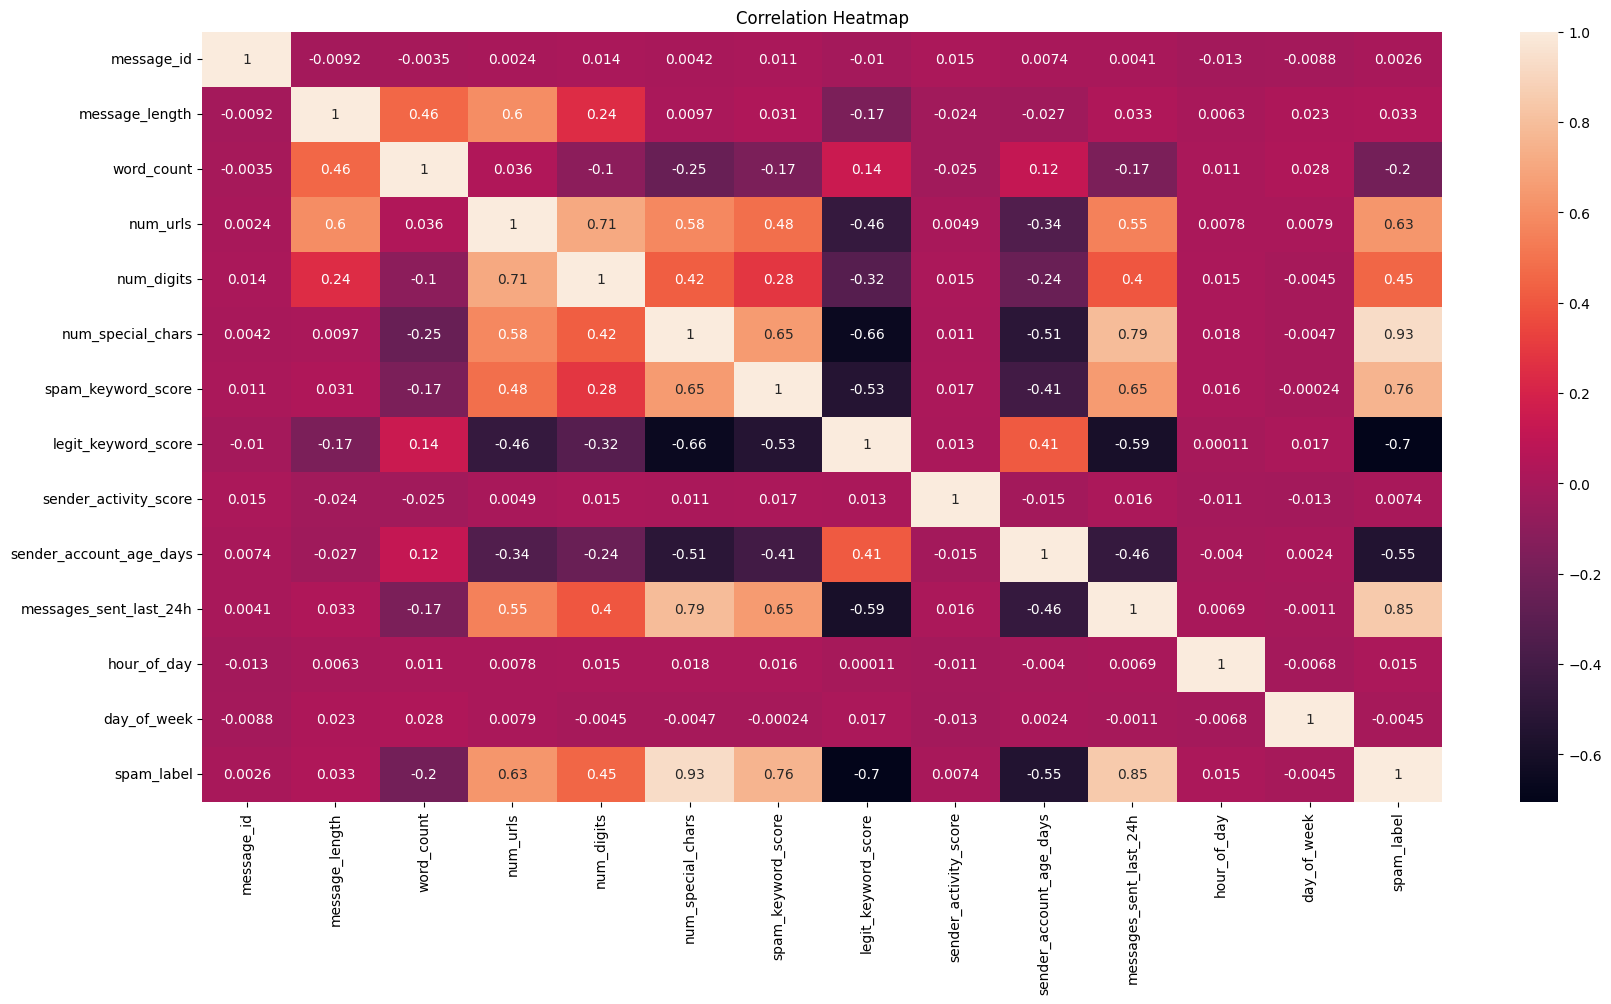

In [8]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### The correlation heatmap shows that num_special_chars (0.93), messages_sent_last_24h (0.85), spam_keyword_score (0.76), and num_urls (0.63) have the strongest positive correlation with the target (spam_label). On the other hand, legit_keyword_score (-0.70) and sender_account_age_days (-0.55) have strong negative correlations, indicating that legitimate messages are associated with genuine keywords and older sender accounts. Features such as sender_activity_score, hour_of_day, and day_of_week show very weak correlations and are less influential for spam prediction.

## Dropping Unnecessary Features

In [9]:
df = df.drop( columns = ['message_id' , 'message_length' , 'sender_activity_score' ,  
    'day_of_week' , 'hour_of_day' , 'timestamp' , 'message_text' ])

### Based on correlation analysis and feature v/s target class boxplots, message_length, sender_activity_score, day_of_week and hour_of_day has very weak relationships with the target variable . Therefore, these features were removed to simplify the model. message_id was dropped because it is a unique identifier and has no prediction information.

## Missing Value Identification

In [10]:
missing_count = df.isnull().sum()
missing_percent = (missing_count/len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)': missing_percent,
})

missing_df

,Missing Count,Missing (%)
word_count,0,0.000000
num_urls,0,0.000000
num_digits,0,0.000000
num_special_chars,0,0.000000
spam_keyword_score,0,0.000000
legit_keyword_score,0,0.000000
sender_account_age_days,113,2.173077
messages_sent_last_24h,162,3.115385
spam_label,0,0.000000


## Train-test Split

In [11]:
X = df.drop('spam_label', axis=1)
y = df['spam_label']

In [12]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 10)

## Missing Value Imputation

In [14]:
num_cols = ['word_count' , 'num_urls' , 'num_digits' , 'num_special_chars' , 'spam_keyword_score' 
            , 'legit_keyword_score' , 'sender_account_age_days' , 'messages_sent_last_24h' ]

robust = RobustScaler()

X_train_scaled = robust.fit_transform(X_train[num_cols])

X_test_scaled = robust.transform(X_test[num_cols])

In [15]:
knn = KNNImputer(n_neighbors = 5 , weights = 'distance')

X_train_imputed = knn.fit_transform(X_train_scaled)

X_test_imputed = knn.transform(X_test_scaled)

In [16]:
X_train_org = robust.inverse_transform(X_train_imputed)

X_test_org = robust.inverse_transform(X_test_imputed)

X_train[num_cols] = X_train_org

X_test[num_cols] = X_test_org

## Feature Scaling

In [17]:
Robust = RobustScaler()

X_train[num_cols] = Robust.fit_transform(X_train[num_cols])
X_test[num_cols] = Robust.transform(X_test[num_cols])

## KNN Classifier

In [18]:
knn_classifier = KNeighborsClassifier() # by default uses n_neighbors = 5 

knn_classifier.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [19]:
y_pred_knn_classifier = knn_classifier.predict(X_test)

In [20]:
tn_knn, fp_knn, fn_knn, tp_knn = confusion_matrix(y_test, y_pred_knn_classifier).ravel()

print("True Positive :", tp_knn)
print("False Negative:", fn_knn)
print("False Positive:", fp_knn)
print("True Negative :", tn_knn)

True Positive : 197
False Negative: 0
False Positive: 0
True Negative : 843


In [21]:
print(classification_report(y_test , y_pred_knn_classifier))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       197

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



In [22]:
print("Precision :", precision_score(y_test, y_pred_knn_classifier))
print("Recall    :", recall_score(y_test, y_pred_knn_classifier))
print("Test F1 Score  :", f1_score(y_test, y_pred_knn_classifier))

Precision : 1.0
Recall    : 1.0
Test F1 Score  : 1.0


### Starified K-Fold Cross-Validation

In [23]:
knn_skf = StratifiedKFold( n_splits = 5 , shuffle = True , random_state = 10)

knn_skf_scores = cross_val_score( knn_classifier , X_train , y_train , cv = knn_skf , scoring = 'f1' )

print("F1 Scores for each fold:", knn_skf_scores)
print("Mean F1 Score:", knn_skf_scores.mean())

F1 Scores for each fold: [1. 1. 1. 1. 1.]
Mean F1 Score: 1.0


## Hyperparamter Tuned KNN Classifier

In [24]:
param_grid = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15]}

tuned_knn = KNeighborsClassifier()

grid = GridSearchCV(estimator = tuned_knn , param_grid = param_grid , cv = 5 , scoring = 'f1' , n_jobs = -1 )

grid.fit(X_train, y_train)

print("Best K :", grid.best_params_)
print("Best CV F1 :", grid.best_score_)

Best K : {'n_neighbors': 1}
Best CV F1 : 1.0


In [25]:
best_knn = grid.best_estimator_

y_pred_tuned_knn = best_knn.predict(X_test)

In [26]:
tn_tuned_knn, fp_tuned_knn, fn_tuned_knn, tp_tuned_knn = confusion_matrix(y_test, y_pred_tuned_knn).ravel()

print("True Positive :", tp_tuned_knn)
print("False Negative:", fn_tuned_knn)
print("False Positive:", fp_tuned_knn)
print("True Negative :", tn_tuned_knn)

True Positive : 197
False Negative: 0
False Positive: 0
True Negative : 843


In [27]:
print(classification_report(y_test, y_pred_tuned_knn))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       197

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



In [28]:
print("Precision :", precision_score(y_test, y_pred_tuned_knn))
print("Recall    :", recall_score(y_test, y_pred_tuned_knn))
print("Test F1 Score  :", f1_score(y_test, y_pred_tuned_knn))

Precision : 1.0
Recall    : 1.0
Test F1 Score  : 1.0


### The baseline KNN classifier (K = 5) achieved perfect classification performance with Precision, Recall, and F1-score all equal to 1.00. Hyperparameter tuning using GridSearchCV (5-fold cross-validation) selected K = 1 as the optimal value, also achieving a mean cross-validation F1-score of 1.00. Since both the baseline and tuned models produced identical performance on the test set, hyperparameter tuning did not provide any measurable improvement.

## SVC - Support Vector Machine Classifier

### kernel = 'linear'

In [29]:
svc_linear = SVC( kernel = 'linear', random_state = 10 )

svc_linear.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [30]:
y_pred_linear_svc = svc_linear.predict(X_test)

In [31]:
tn_svc_linear, fp_svc_linear, fn_svc_linear, tp_svc_linear = confusion_matrix(y_test, y_pred_linear_svc).ravel()

print("True Positive :", tp_svc_linear)
print("False Negative:", fn_svc_linear)
print("False Positive:", fp_svc_linear)
print("True Negative :", tn_svc_linear)

True Positive : 197
False Negative: 0
False Positive: 0
True Negative : 843


In [32]:
print(classification_report(y_test, y_pred_linear_svc))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       197

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



In [33]:
print("Precision :", precision_score(y_test, y_pred_linear_svc))
print("Recall    :", recall_score(y_test, y_pred_linear_svc))
print("Test F1 Score  :", f1_score(y_test, y_pred_linear_svc))

Precision : 1.0
Recall    : 1.0
Test F1 Score  : 1.0


### Stratified K-Fold Cross-Validation

In [34]:
linear_svc_skf = StratifiedKFold( n_splits = 5 , shuffle = True , random_state = 10)

linear_svc_skf_scores = cross_val_score( svc_linear , X_train , y_train , cv = linear_svc_skf , scoring = 'f1' )

print("F1 Scores for each fold:", linear_svc_skf_scores)
print("Mean F1 Score:", linear_svc_skf_scores.mean())

F1 Scores for each fold: [1. 1. 1. 1. 1.]
Mean F1 Score: 1.0


### kernel = 'rbf'

In [35]:
svc_rbf = SVC( kernel = 'rbf', random_state = 10 )

svc_rbf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [36]:
y_pred_rbf_svc = svc_rbf.predict(X_test)

In [ ]:
tn_svc_rbf, fp_svc_rbf, fn_svc_rbf, tp_svc_rbf = confusion_matrix(y_test, y_pred_linear_svc).ravel()

print("True Positive :", tp_svc_rbf)
print("False Negative:", fn_svc_rbf)
print("False Positive:", fp_svc_rbf)
print("True Negative :", tn_svc_rbf)

True Positive : 197
False Negative: 0
False Positive: 0
True Negative : 843


In [38]:
print(classification_report(y_test, y_pred_rbf_svc))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       197

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



In [39]:
print("Precision :", precision_score(y_test, y_pred_rbf_svc))
print("Recall    :", recall_score(y_test, y_pred_rbf_svc))
print("Test F1 Score  :", f1_score(y_test, y_pred_rbf_svc))

Precision : 1.0
Recall    : 1.0
Test F1 Score  : 1.0


### Stratified K-Fold Cross-Validation

In [40]:
rbf_svc_skf = StratifiedKFold( n_splits = 5 , shuffle = True , random_state = 10)

rbf_svc_skf_scores = cross_val_score( svc_rbf , X_train , y_train , cv = rbf_svc_skf , scoring = 'f1' )

print("F1 Scores for each fold:", rbf_svc_skf_scores)
print("Mean F1 Score:", rbf_svc_skf_scores.mean())

F1 Scores for each fold: [1. 1. 1. 1. 1.]
Mean F1 Score: 1.0


### Both Linear and RBF SVM achieved 100% Precision, Recall, and F1-score. The cross-validation results were also perfect (Mean F1 = 1.00), showing that the models are consistent and the dataset is highly separable using the selected features.

## Naive Bayes Classifier & Probability

In [41]:
naive = GaussianNB()

naive.fit(X_train , y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [42]:
y_pred_naive = naive.predict(X_test)

In [43]:
tn_naive, fp_naive, fn_naive, tp_naive = confusion_matrix(y_test, y_pred_naive).ravel()

print("True Positive :", tp_naive)
print("False Negative:", fn_naive)
print("False Positive:", fp_naive)
print("True Negative :", tn_naive)

True Positive : 197
False Negative: 0
False Positive: 0
True Negative : 843


In [44]:
print(classification_report(y_test , y_pred_naive))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       197

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



In [45]:
print("Precision :", precision_score(y_test, y_pred_naive))
print("Recall    :", recall_score(y_test, y_pred_naive))
print("Test F1 Score  :", f1_score(y_test, y_pred_naive))

Precision : 1.0
Recall    : 1.0
Test F1 Score  : 1.0


### Stratified K-Fold Cross-Validation 

In [46]:
naive_skf = StratifiedKFold( n_splits = 5 , shuffle = True , random_state = 10)

naive_skf_scores = cross_val_score( naive , X_train , y_train , cv = naive_skf , scoring = 'f1' )

print("F1 Scores for each fold:", naive_skf_scores)
print("Mean F1 Score:", naive_skf_scores.mean())

F1 Scores for each fold: [1. 1. 1. 1. 1.]
Mean F1 Score: 1.0


### Conditional Probability

In [49]:
spam = X_train[y_train == 1]
legit = X_train[y_train == 0]

prob_url_given_spam = (spam['num_urls'] > 0).mean()

prob_url_given_legit = (legit['num_urls'] > 0).mean()

print("P(URL > 0 | Spam) : " , round(prob_url_given_spam,4))
print("P(URL > 0 | Legitimate) : " , round(prob_url_given_legit,4))

P(URL > 0 | Spam) :  0.7397
P(URL > 0 | Legitimate) :  0.0851


### The conditional probability represents the likelihood of observing a feature given a particular class. If P(URL > 0 | Spam) is much higher than P(URL > 0 | Legitimate), then the presence of URLs is a strong indicator that a message is spam.

### Bayes Theorem 

In [50]:
prob_spam = (y_train == 1).mean()
prob_legit = (y_train == 0).mean()

prob_url = (X_train['num_urls'] > 0).mean()

posterior_spam = (prob_url_given_spam * prob_spam) / prob_url

print("P(Spam) : " , round(prob_spam,4))
print("P(Legitimate) : " , round(prob_legit,4))
print("P(URL > 0) : " , round(prob_url,4))
print("P(Spam | URL > 0) : " , round(posterior_spam,4))

P(Spam) :  0.1865
P(Legitimate) :  0.8135
P(URL > 0) :  0.2072
P(Spam | URL > 0) :  0.6659


### Bayes theorem combines the prior probability of spam with the likelihood of observing URLs in spam messages to compute the posterior probability that a message is spam. A higher posterior probability indicates that messages containing URLs are more likely to belong to the spam class.

### Comparing theoretical probability calculations with model predictions

In [54]:
probability = naive.predict_proba(X_test)

comparison = X_test.copy()

comparison['Actual'] = y_test.values    
comparison['Predicted'] = naive.predict(X_test)

comparison['P(Legitimate)'] = probability[:,0].round(0)
comparison['P(Spam)'] = probability[:,1].round(0)

comparison[['Actual','Predicted','P(Legitimate)','P(Spam)']].head(10)

,Actual,Predicted,P(Legitimate),P(Spam)
1373,1,1,0.0,1.0
930,1,1,0.0,1.0
4692,0,0,1.0,0.0
1758,1,1,0.0,1.0
1841,0,0,1.0,0.0
2419,0,0,1.0,0.0
989,0,0,1.0,0.0
3063,0,0,1.0,0.0
2411,0,0,1.0,0.0
658,0,0,1.0,0.0


### The model is making highly confident and mostly correct predictions in these cases.

## Model Comparison & Evaluation

In [55]:
Metric_Results = pd.DataFrame({
    'Model' : ['KNN Classifier' , 'SVC ( Linear )' , 'SVC ( RBF )' , 'Naive Bayes Classifier'],
    'TP' : [tp_knn , tp_svc_linear , tp_svc_rbf , tp_naive],
    'FN' : [fn_knn , fn_svc_linear , fn_svc_rbf , fn_naive],
    'FP' : [fp_knn , fp_svc_linear , fp_svc_rbf , fp_naive],
    'TN' : [tn_knn , tn_svc_linear , tn_svc_rbf , tn_naive]
})

Metric_Results

,Model,TP,FN,FP,TN
0,KNN Classifier,197,0,0,843
1,SVC ( Linear ),197,0,0,843
2,SVC ( RBF ),197,0,0,843
3,Naive Bayes Classifier,197,0,0,843


In [56]:
Results = pd.DataFrame({
    'Model' : ['KNN Classifier' , 'SVC ( Linear )' , 'SVC ( RBF )' , 'Naive Bayes Classifier'],
    'Precision' : [precision_score(y_test, y_pred_knn_classifier) , precision_score(y_test, y_pred_linear_svc) ,
                    precision_score(y_test, y_pred_rbf_svc) , precision_score(y_test, y_pred_naive)],
    'Recall' : [recall_score(y_test, y_pred_knn_classifier) , recall_score(y_test, y_pred_linear_svc) ,
                recall_score(y_test, y_pred_rbf_svc) , recall_score(y_test, y_pred_naive)],
    'Test F1' : [f1_score(y_test, y_pred_knn_classifier) , f1_score(y_test, y_pred_linear_svc) ,
                f1_score(y_test, y_pred_rbf_svc) , f1_score(y_test, y_pred_naive)],
    'Average Stratified CV' : [knn_skf_scores.mean() , linear_svc_skf_scores.mean() ,
                                rbf_svc_skf_scores.mean() , naive_skf_scores.mean()]    
})

Results

,Model,Precision,Recall,Test F1,Average Stratified CV
0,KNN Classifier,1.0,1.0,1.0,1.0
1,SVC ( Linear ),1.0,1.0,1.0,1.0
2,SVC ( RBF ),1.0,1.0,1.0,1.0
3,Naive Bayes Classifier,1.0,1.0,1.0,1.0


### All models performed equally well with 100% accurate prediction and perfect classification metrics, suggesting that the dataset is highly separable or possibly very simple for the given features.